# Chronic Kidney Disease (CKD) Indicators

Research Question: What are the key medical indicators and their relationships that predicts Chronic Kidney Disease(CKD)?

Dataset Description:

1. Creatinine: 	Blood creatinine level (mg/dL). High values indicate reduced kidney filtration.

2. BUN: Blood Urea Nitrogen (mg/dL). Elevated levels indicate impaired kidney function.

3. GFR: 	Glomerular Filtration Rate (5–120). Higher = better kidney function.

4. Urine_output: 	Daily urine volume (mL/day). Low output may reflect kidney damage.

5. Diabetes: Whether the patient has diabetes, a major CKD risk factor. 0= Non diabetic 1= Diabetic

6. Hypertension: 	High blood pressure status, strongly linked to CKD progression. 0= No hypertension 1= Hypertension

7. Age: Patient age (18–90). Kidney function decreases with age.

8. Protein_in_Urine: Proteinuria level (mg/dL). High protein = kidney damage.

9. Water_Intake: Daily water consumption (liters/day).

10. Medication: 	Type of medication: None, ACE Inhibitor, ARB, Diuretic.


## 1. Importing libraries

In [ ]:
# Bringing external libraries into this session to make it's functions and tools available for use

import pandas as pd  # Loads pandas library for managing and analyzing tabular data
import numpy as np   # Loads NumPy library for fast mathematical operations

import matplotlib.pyplot as plt # Loads Pyplot module from Matplotlib to create charts and figures
import seaborn as sns # Loads Seaborn Library to create high level graphics


## 2. Loading Dataset

In [ ]:
# Reading the uploaded csv file from GitHub

df = pd.read_csv('https://raw.githubusercontent.com/rs243/PythonDataAnalytics/refs/heads/main/kidney_dataset.csv')



## 3. Data Overview

In [ ]:
# First 10 rows

print('First 10 rows:')
display(df.head(10))      # Displays the first 10 rows


First 10 rows:


,Creatinine,BUN,GFR,Urine_Output,Diabetes,Hypertension,Age,Protein_in_Urine,Water_Intake,Medication,CKD_Status
0,0.788803,8.386869,102.161787,1632.649387,0,0,27.682074,106.700203,1.570370,NaN,0
1,3.413970,53.688796,50.071257,935.540516,1,0,33.122208,410.008362,3.425287,ACE Inhibitor,1
2,0.647645,7.466540,89.451831,1774.553846,1,1,55.832284,123.336925,1.123301,Diuretic,0
3,0.795508,12.516821,99.872180,2360.602980,0,0,32.391900,116.098870,3.086846,ACE Inhibitor,0
4,0.869010,19.855960,86.110182,1987.750901,0,1,66.689515,55.668760,2.174980,ARB,0
5,0.712243,18.360351,95.790747,1742.261085,0,0,48.933196,122.531114,2.735247,ARB,0
6,5.115105,36.702973,29.982242,845.191506,0,1,51.283921,1122.938762,2.776777,ARB,1
7,5.654248,75.627081,5.905070,682.343581,1,1,45.824405,1796.981457,3.132385,ACE Inhibitor,1
8,2.874185,109.623087,36.955744,1199.330090,0,0,61.592718,1116.190230,1.612787,NaN,1
9,1.104140,11.793995,85.578023,2213.989276,1,0,61.747398,94.873882,2.594158,NaN,0


In [ ]:
# Last 10 rows

print('Last 10 rows:')    # Displays the last 10 rows
display(df.tail(10))


Last 10 rows:


,Creatinine,BUN,GFR,Urine_Output,Diabetes,Hypertension,Age,Protein_in_Urine,Water_Intake,Medication,CKD_Status
4990,3.864917,47.373125,33.977746,1199.774178,1,0,64.730165,2495.095244,3.011495,NaN,1
4991,0.737223,15.560690,97.426942,1834.298906,0,0,43.538426,116.829519,1.343388,NaN,0
4992,1.147212,8.419874,97.431300,1579.332534,0,0,30.040264,89.380274,3.236386,ARB,0
4993,0.920869,19.396278,91.020372,1860.671564,0,1,38.435015,141.104248,2.258328,NaN,0
4994,0.780075,10.826065,98.247818,1681.327580,0,0,44.773007,62.953885,2.689324,ARB,0
4995,4.048737,53.094020,24.964596,1179.120228,1,1,64.910042,2846.781763,3.403640,NaN,1
4996,0.787392,7.598859,94.228637,2029.623102,0,1,49.365980,56.600073,1.759214,ACE Inhibitor,0
4997,1.177967,10.198228,89.099101,2463.843638,0,1,47.207777,88.090385,2.238708,NaN,0
4998,1.189794,12.446732,90.539937,1851.314122,1,0,31.270049,64.837267,3.188672,NaN,0
4999,1.000078,11.804883,91.697611,2056.462819,0,0,61.782239,134.514375,3.755283,ACE Inhibitor,0


In [ ]:
# Shape of dataset

print('Shape (rows, columns):', df.shape)  # Displays the total rows and columns


Shape (rows, columns): (5000, 11)


In [ ]:
# Listing all column names

print('Column names:')
print(df.columns.tolist()) # Displays the column titles


Column names:
['Creatinine', 'BUN', 'GFR', 'Urine_Output', 'Diabetes', 'Hypertension', 'Age', 'Protein_in_Urine', 'Water_Intake', 'Medication', 'CKD_Status']


## 4. Basic Data Cleaning

In [ ]:
# Clean column names

df.columns = (
    df.columns
      .str.strip()  # Removes any leading or trailing white spaces
      .str.lower()  # Comverts all characters to lowercase
      .str.replace(' ', '_')  # Replaces the spaces with underscores
      .str.replace('-', '_')  # Replaces the hyphens with underscores
)
df.columns  # Displays the columns after changes made


Index(['creatinine', 'bun', 'gfr', 'urine_output', 'diabetes', 'hypertension',
       'age', 'protein_in_urine', 'water_intake', 'medication', 'ckd_status'],
      dtype='object')

In [ ]:
# Checking number of duplicate rows

num_duplicates = df.duplicated().sum() # Scans dataframe for repeated rows, adds up the repeated rows and stores it in variable num_duplicates
print('Number of duplicate rows:', num_duplicates)


Number of duplicate rows: 0


## 5. Finding missing Values

In [ ]:
# Missing value per column

print('Missing values per column:')
display(df.isna().sum())  # Scans dataframe for NaN, adds up NaN for each column and displays it


Missing values per column:


,0
creatinine,0
bun,0
gfr,0
urine_output,0
diabetes,0
hypertension,0
age,0
protein_in_urine,0
water_intake,0
medication,2987


In [ ]:
# Value counts for medication column

print(f"\nColumn: {'medication'}")
display(df['medication'].value_counts(dropna=False).sort_values(ascending=False))  # Targets medication column, counts the total number of each unique values including NaN and displays it in descending order of occurrence



Column: medication


,count
medication,
NaN,2987
ACE Inhibitor,1013
ARB,779
Diuretic,221


## 6. Filling in the missing values

In [ ]:
# Checking the data types

df.dtypes


,0
creatinine,float64
bun,float64
gfr,float64
urine_output,float64
diabetes,int64
hypertension,int64
age,float64
protein_in_urine,float64
water_intake,float64
medication,object


In [ ]:
# Converting object data types into category

cat_cols = ['medication']  # Storing names of categorical columns into a variable for data visualization later

for col in cat_cols:  # Replaying each columns listed in cat_cols variable
  df[col] = df[col].astype('category')  # Changing the data type from object to categorical type

df[cat_cols].dtypes  # Lists data type only for columns listed in cat_cols variable


,0
medication,category


In [ ]:
# Using fillna() to replace NaN in the categorical columns by "Unknown"

for col in cat_cols:  # Replaying each columns listed in cat_cols variable

# Add 'Unknown' to the categories if it's not already there

  if 'Unknown' not in df[col].cat.categories:  # Checks if 'Unknown' is already in the category
    df[col] = df[col].cat.add_categories('Unknown')  # If not in the category adds unknown to the list of categories
  df[col] = df[col].fillna('Unknown')  #  Fills every NaN value in that column with 'Unknown'

print(df.isna().sum())  # Checking to see if the missing values in medication column has been filled


creatinine          0
bun                 0
gfr                 0
urine_output        0
diabetes            0
hypertension        0
age                 0
protein_in_urine    0
water_intake        0
medication          0
ckd_status          0
dtype: int64


In [ ]:
# Checking if the NaN has been replaced with Unknown in medication column

print(f"\nColumn: {'medication'}")
display(df['medication'].value_counts(dropna=False).sort_values(ascending=False))  # Shows the updated medication column counts after cleaning



Column: medication


,count
medication,
Unknown,2987
ACE Inhibitor,1013
ARB,779
Diuretic,221


No need to convert numerical columns as it is already in the correct data type

In [ ]:
# Listing numerical and categorical columns

num_cols = df.select_dtypes(include=['int64', 'float64']).columns.tolist()  # Filters to keep only columns with int64 or float64 data types and stores in the num_cols variable
print('Numeric columns:', num_cols)

cat_cols = df.select_dtypes(include=['category']).columns.tolist()  # Filters to keep only columns with category data type and stores in the cat_cols variable
print('Categorical columns:', cat_cols)


Numeric columns: ['creatinine', 'bun', 'gfr', 'urine_output', 'diabetes', 'hypertension', 'age', 'protein_in_urine', 'water_intake', 'ckd_status']
Categorical columns: ['medication']


## 7. Exploratory Data Analysis (EDA)

In [ ]:
# Descriptive statistics

print('Descriptive statistics for numeric columns:')
display(df[num_cols].describe())  # Calculates and lists a summary table with descriptive statistics like mean, standard deviation etc


Descriptive statistics for numeric columns:


,creatinine,bun,gfr,urine_output,diabetes,hypertension,age,protein_in_urine,water_intake,ckd_status
count,5000.000000,5000.000000,5000.000000,5000.000000,5000.000000,5000.000000,5000.000000,5000.000000,5000.000000,5000.000000
mean,1.994088,30.780063,73.251883,1664.302800,0.294000,0.378200,50.048733,537.053851,2.504335,0.263000
std,2.027013,31.148341,31.972399,599.384655,0.455637,0.484986,14.492020,817.510451,0.868925,0.440306
min,0.600040,7.007732,5.000000,400.502554,0.000000,0.000000,18.000000,50.010471,1.000810,0.000000
25%,0.801333,11.367599,53.036801,1105.890821,0.000000,0.000000,40.190016,83.692533,1.744138,0.000000
50%,1.007629,15.878566,89.555882,1814.499690,0.000000,0.000000,49.942824,119.492591,2.511710,0.000000
75%,2.163997,40.636666,93.989273,2146.441778,1.000000,1.000000,59.761132,588.428649,3.268812,1.000000
max,7.996428,119.931652,105.451432,2499.939696,1.000000,1.000000,90.000000,2997.724192,3.998043,1.000000


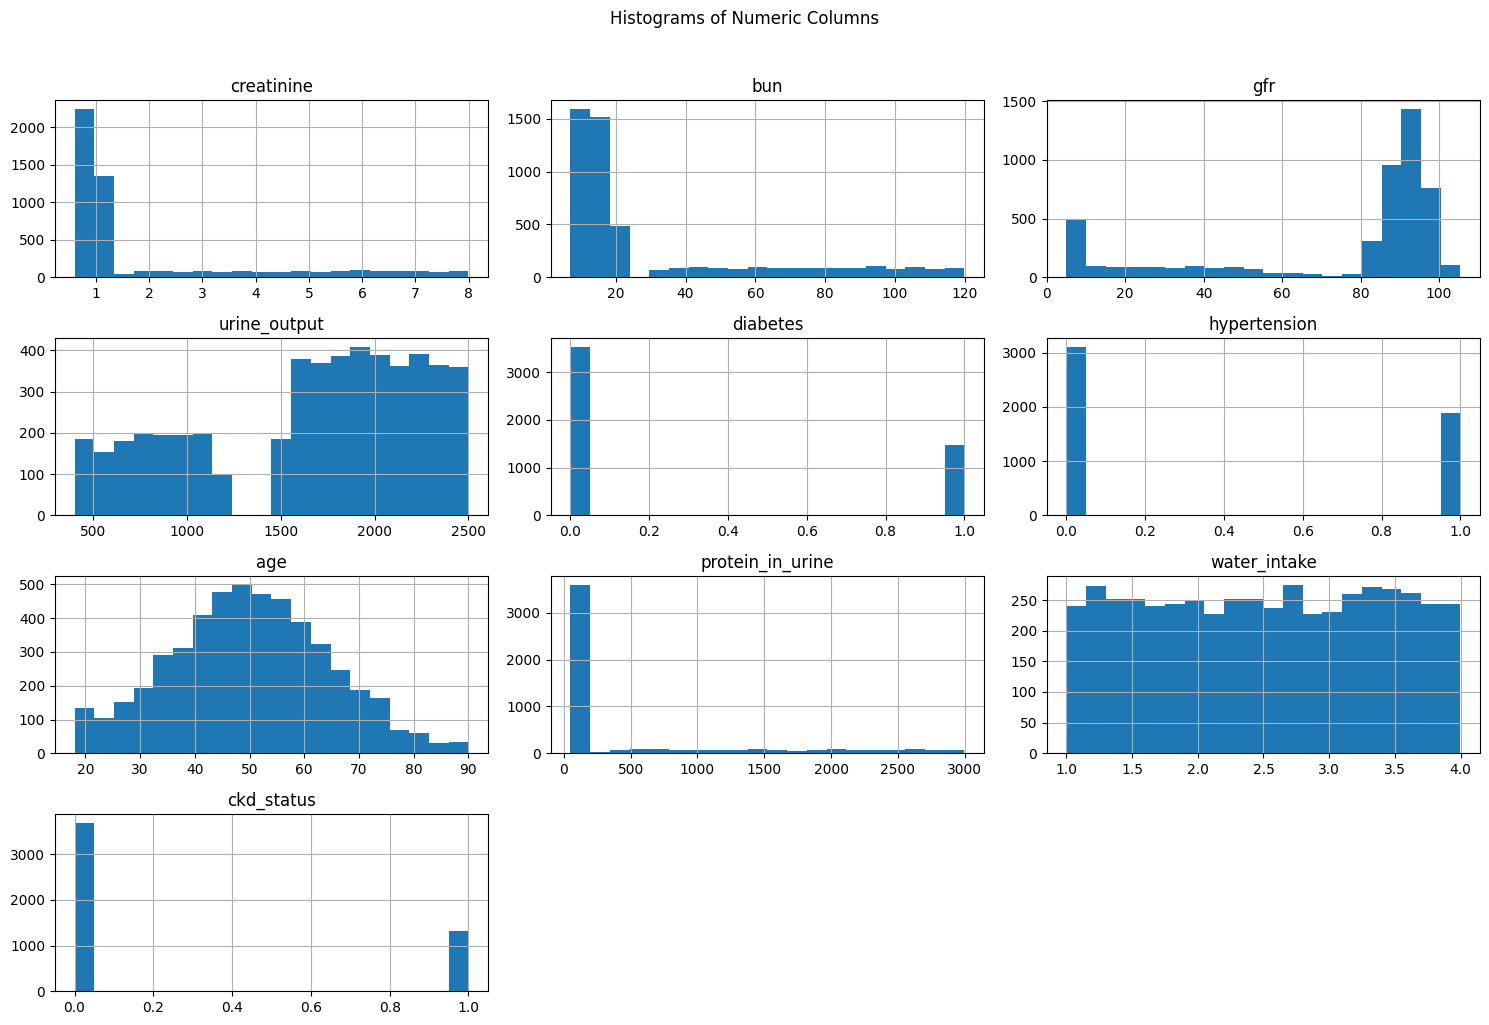

In [ ]:
# Histogram for all numeric columns

df[num_cols].hist(figsize=(15,10), bins=20)  # Generates histograms for all numeric column at once, figsize sets the total size and bins sets the bar detail level
plt.suptitle('Histograms of Numeric Columns', y=1.02)  # Adds a main title across the top of the charts
plt.tight_layout()  # Adjusts the spacing so labels and subplots don't overlap
plt.show()  # Displays the final Matplotlib figure


The histograms of creatinine, bun and protein_in_urine shows a right-skewed distribution. This means that most people have relatively lower values, which are considered healthly. But the long tail extending to the right indicates that there are people with high values indicating of kidney dysfunction or presence of outliers.

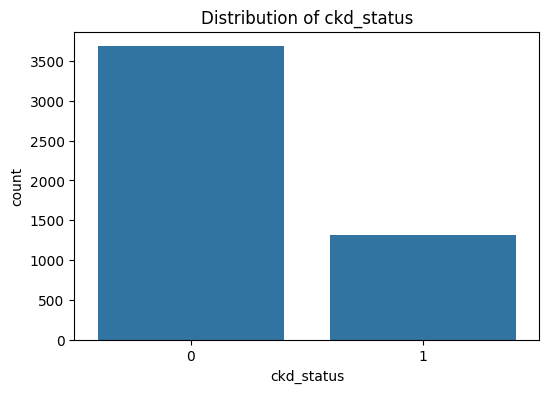

In [ ]:
# Countplot for ckd_status

plt.figure(figsize=(6,4))  # Initializes a Matplotlib figure with width(6) and height(4)
sns.countplot(x='ckd_status', data=df)  # Uses Seaborn to count the number of times each status appears and draws them as bars
plt.title(f'Distribution of {'ckd_status'}')  #  Adds main title on the top of the chart
plt.show()  # Displays final plot


The countplot shows the distribution of CKD in the dataset where

0 = No CKD and 1 = CKD

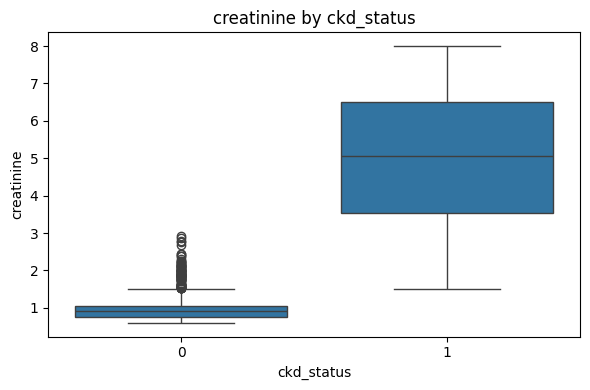

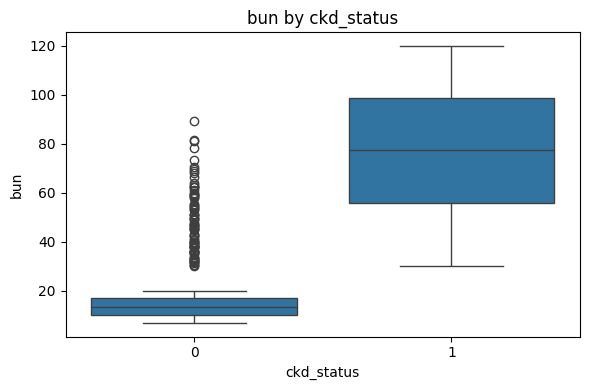

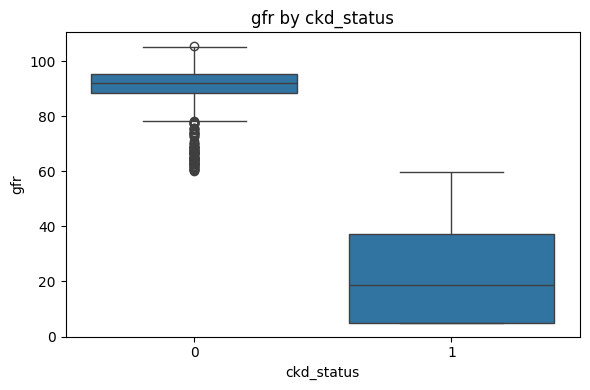

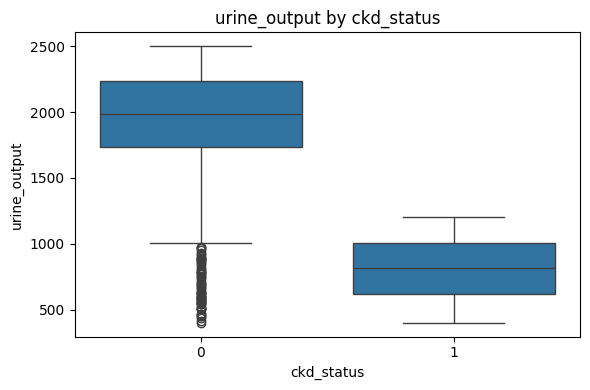

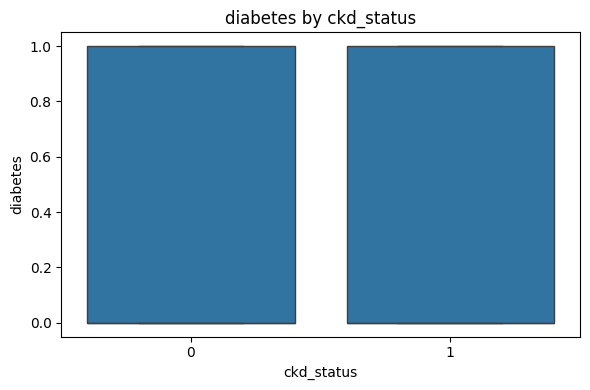

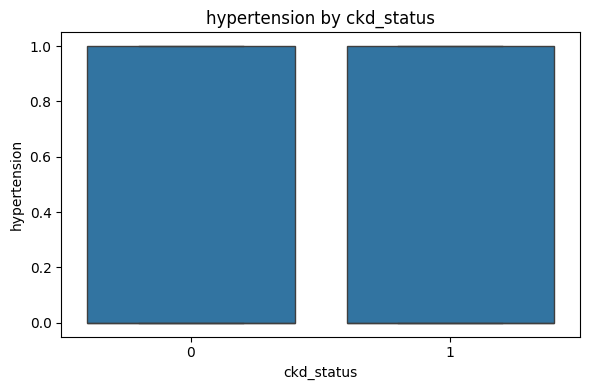

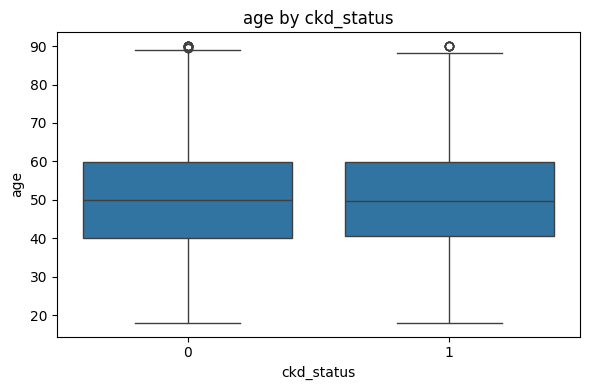

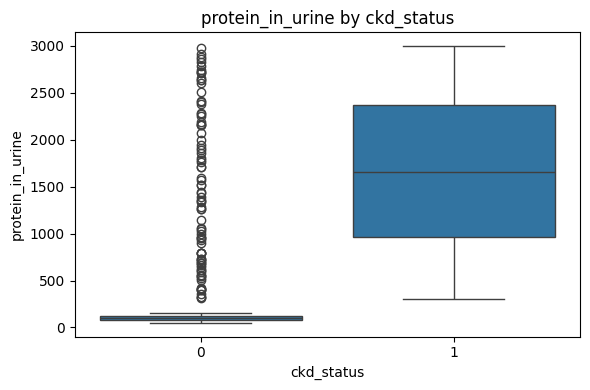

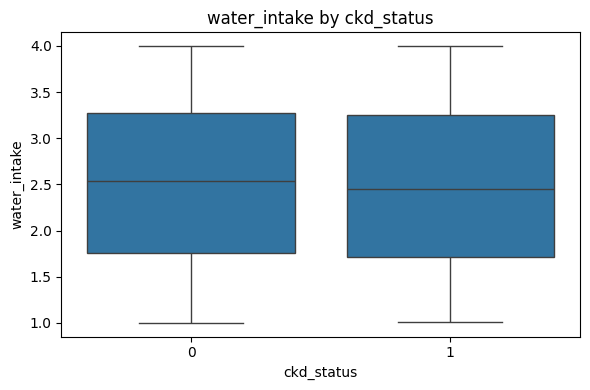

In [ ]:
# Numeric columns vs ckd_status

num_cols_analysis = ['creatinine', 'bun', 'gfr', 'urine_output', 'diabetes', 'hypertension', 'age', 'protein_in_urine', 'water_intake']  # Storing names of numerical columns into a variable for data visualization


for col in num_cols_analysis:  # Replaying each columns listed in num_cols_analysis variable
        plt.figure(figsize=(6, 4))  # Initializes a Matplotlib figure with width(6) and height(4)
        sns.boxplot(x='ckd_status', y=col, data=df)  # Uses Seaborn to draw box and whiskers plots, showing the distribution of median, quartiles and outliers of a numerical column for each CKD status
        plt.title(f'{col} by {'ckd_status'}')  # Add dynamic title indicating the variable being analyzed
        plt.tight_layout()  # Adjusts the spacing so labels and subplots don't overlap
        plt.show()  # Displays final plot


The boxplots shows the patients with CKD tends to have higher levels of creatinine, bun and protein_in_urine and lower gfr values which aligns with clinical patterns of kidney disease progression. It also shows significant amount of outliers in creatine, bun and protein_in_urine.

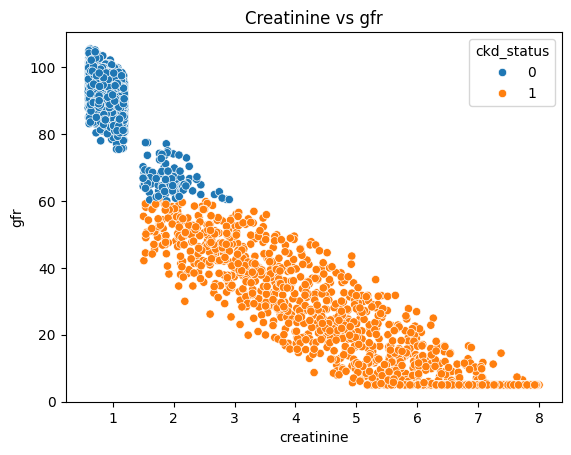

In [ ]:
# Creatinine vs gfr

sns.scatterplot(data=df, x="creatinine", y="gfr", hue="ckd_status")  # Uses Seaborn to draw scatterplot with x(creatinine), y(grf) and colors the points based on ckd_status
plt.title("Creatinine vs gfr")  # Adds main title on top of the chart
plt.show()  # Displays final plot


The scatterplot shows a clear inverse relationship between creatinine and gfr, especially in people with CKD. It aligns with the understanding that waste products like creatinine accumulates in blood when kidney function declines.

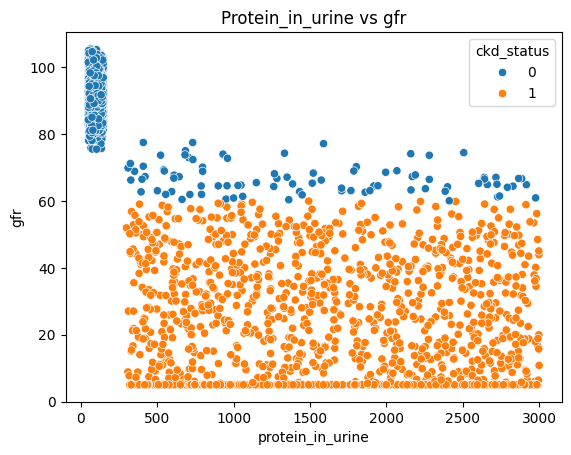

In [ ]:
# Protein_in_urine vs gfr

sns.scatterplot(data=df, x="protein_in_urine", y="gfr", hue="ckd_status")  # Uses Seaborn to draw scatterplot with x(protein_in_urine), y(grf) and colors the points based on ckd_status
plt.title("Protein_in_urine vs gfr")  # Adds main title on top of the chart
plt.show()  # Displays final plot


The scatterplot shows a clear inverse relationship between protein_in_urine and gfr, especially in people with CKD. It aligns with the understanding that damage to the kidney's filtering units can lead to the leakage of protein into the urine, which is a indicator of CKD

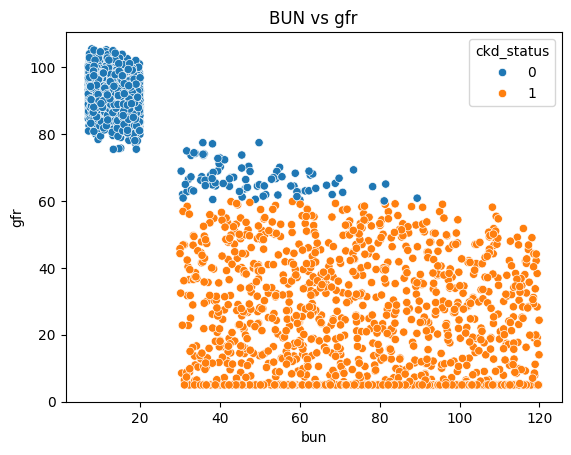

In [ ]:
# Bun vs gfr

sns.scatterplot(data=df, x="bun", y="gfr", hue="ckd_status")  # Uses Seaborn to draw scatterplot with x(bun), y(grf) and colors the points based on ckd_status
plt.title("BUN vs gfr")  # Adds main title on top of the chart
plt.show()  # Displays final plot


The scatterplot shows a clear inverse relationship between bun and gfr, especially in people with CKD. It aligns with the understanding that as kidney function declines, waste products like BUN accumulate in the blood.

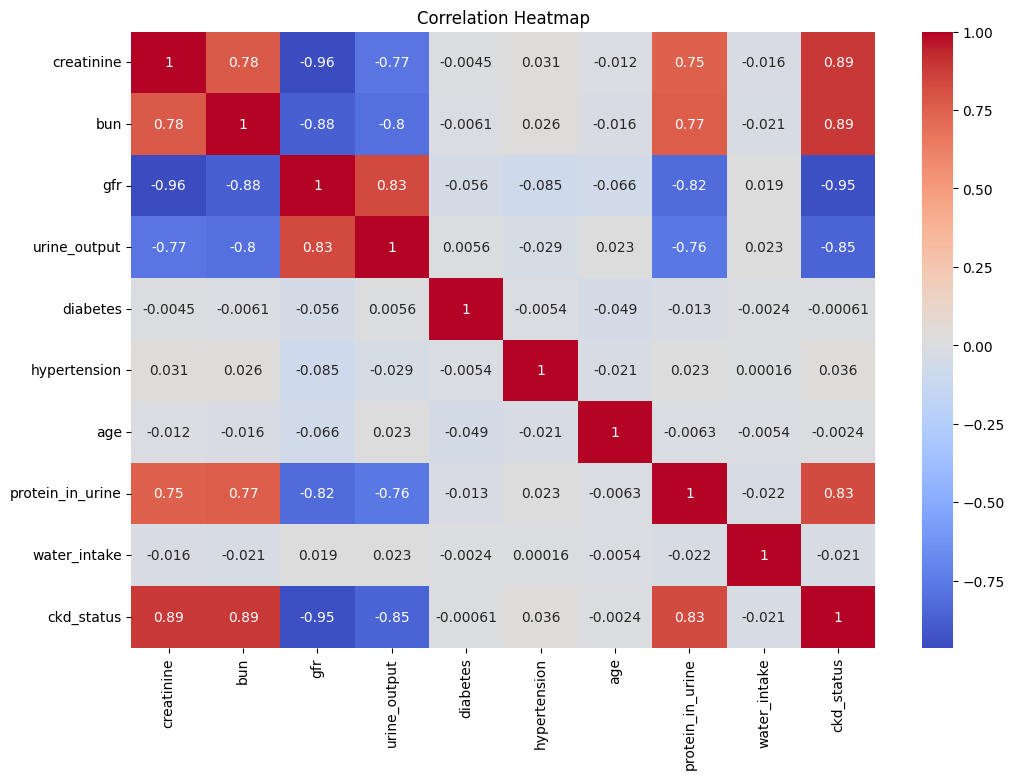

In [ ]:
# Correlation heatmap for finding patterns between variables

plt.figure(figsize=(12,8))  # Initializes large Matplotlib canvas with width(12) and height(8)
sns.heatmap(df.corr(numeric_only=True), annot=True, cmap="coolwarm")  # Uses Seaborn to draw grid, calculates the correlation coefficients (ranging from -1 to 1) between all the numeric columns where annot=True writes the actual numbers in boxes and coolwarm colors high correlations as red and low ones as blue
plt.title("Correlation Heatmap")  # Adds the title on top
plt.show()  # Displays the final map


The heatmap reveals a strong positive correlations between creatinine, bun and protein_in_urine and these kidney function markers with ckd_status. Whereas showed a negative correlations with gfr which is expected.

### 8. Outlier Detection

In [ ]:
print('Outliers (using IQR method):')
for col in num_cols_analysis: # Replaying each numerical column for outlier detection
    Q1 = df[col].quantile(0.25) # Calculates the first quartile (25th percentile)
    Q3 = df[col].quantile(0.75) # Calculates the third quartile (75th percentile)
    IQR = Q3 - Q1 # Calculates the Interquartile Range
    lower_bound = Q1 - 1.5 * IQR # Defines the lower bound for outlier detection
    upper_bound = Q3 + 1.5 * IQR # Defines the upper bound for outlier detection

    # Identifies outliers using the calculated bounds
    outliers = df[(df[col] < lower_bound) | (df[col] > upper_bound)]

    print(f"\nColumn '{col}': {len(outliers)} outliers found.") # Prints the number of outliers for each column
    if not outliers.empty: # If outliers are found, display the first 5
        display(outliers.head())

Outliers (using IQR method):

Column 'creatinine': 842 outliers found.


,creatinine,bun,gfr,urine_output,diabetes,hypertension,age,protein_in_urine,water_intake,medication,ckd_status
6,5.115105,36.702973,29.982242,845.191506,0,1,51.283921,1122.938762,2.776777,ARB,1
7,5.654248,75.627081,5.905070,682.343581,1,1,45.824405,1796.981457,3.132385,ACE Inhibitor,1
18,6.989712,118.999881,5.000000,1082.777918,0,0,39.663323,331.223039,1.748754,Unknown,1
22,6.332741,70.493508,11.100524,823.148872,0,1,31.151520,509.409307,2.109308,ACE Inhibitor,1
25,6.947599,116.409207,5.000000,518.223897,1,0,59.010995,2464.780326,1.485194,ACE Inhibitor,1



Column 'bun': 559 outliers found.


,creatinine,bun,gfr,urine_output,diabetes,hypertension,age,protein_in_urine,water_intake,medication,ckd_status
8,2.874185,109.623087,36.955744,1199.330090,0,0,61.592718,1116.190230,1.612787,Unknown,1
12,2.598202,104.327709,40.892761,661.391464,1,0,46.818655,755.589240,2.487183,Unknown,1
17,4.024503,118.627020,19.065226,829.413707,0,0,43.141722,2808.096847,3.630264,Unknown,1
18,6.989712,118.999881,5.000000,1082.777918,0,0,39.663323,331.223039,1.748754,Unknown,1
21,2.911498,115.615542,34.712649,1013.486652,0,0,67.566530,717.135151,2.544984,ARB,1



Column 'gfr': 0 outliers found.

Column 'urine_output': 0 outliers found.

Column 'diabetes': 0 outliers found.

Column 'hypertension': 0 outliers found.

Column 'age': 15 outliers found.


,creatinine,bun,gfr,urine_output,diabetes,hypertension,age,protein_in_urine,water_intake,medication,ckd_status
195,1.123631,13.888048,80.257045,1576.843659,0,1,89.550037,60.988316,1.302906,Unknown,0
265,2.185058,111.058963,30.000256,594.852239,1,0,90.000000,2487.121443,2.168404,ARB,1
348,3.359786,67.813492,38.817428,642.389924,0,0,90.000000,840.364432,1.029190,Unknown,1
411,0.853767,15.930501,81.599830,1694.584033,1,0,90.000000,125.270414,1.297389,Unknown,0
826,2.996193,66.675296,37.331760,1007.661345,0,1,90.000000,1570.446392,2.642342,Unknown,1



Column 'protein_in_urine': 861 outliers found.


,creatinine,bun,gfr,urine_output,diabetes,hypertension,age,protein_in_urine,water_intake,medication,ckd_status
7,5.654248,75.627081,5.905070,682.343581,1,1,45.824405,1796.981457,3.132385,ACE Inhibitor,1
17,4.024503,118.627020,19.065226,829.413707,0,0,43.141722,2808.096847,3.630264,Unknown,1
25,6.947599,116.409207,5.000000,518.223897,1,0,59.010995,2464.780326,1.485194,ACE Inhibitor,1
38,7.071267,39.153206,5.000000,1142.295289,0,1,72.431874,1357.201264,1.090065,Unknown,1
39,6.266292,85.401262,5.000000,975.702876,0,1,45.730617,2635.104434,1.734940,Unknown,1



Column 'water_intake': 0 outliers found.


protein_in_urine: 861 outliers

creatinine: 842 outliers

bun: 559 outliers

age: 15 outliers


Columns like 'creatinine', 'bun', 'age', and 'protein_in_urine' show a significant number of outliers, which might indicate extreme values or data entry issues. Columns like 'gfr', 'urine_output', 'diabetes', 'hypertension', and 'water_intake' appear to have no outliers based on this method.

## 9. Conclusion

It can be concluded that key medical indicators like creatinine, BUN, and protein in urine are significantly higher, and GFR is lower in patients with Chronic Kidney Disease (CKD). Diabetes and hypertension are also strong risk factors. The analysis also highlighted the significant presence of outliers in creatinine, BUN and protein in urine.

## 10. Save cleaned dataset

In [ ]:
output_file = 'PythonCapstoneProjectCKD_cleaned.csv'
df.to_csv(output_file, index=False)
print(f'Cleaned data saved to {output_file}')


Cleaned data saved to PythonCapstoneProjectCKD_cleaned.csv
